<a href="https://colab.research.google.com/github/sayma-code/Artificial-Intelligence-and-Smart-Energy/blob/main/Midterm_Question_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

In [ ]:
g = 9.81

In [ ]:
def projectile_motion(v0, angle_deg, t):
    angle = np.radians(angle_deg)
    vx = v0 * np.cos(angle)
    vy = v0 * np.sin(angle)
    x = vx * t
    y = vy * t - 0.5 * g * t**2
    return x, y

In [ ]:
N = 3000
v0_vals = np.random.uniform(20, 60, N)
angle_vals = np.random.uniform(20, 70, N)
time_vals = np.random.uniform(0, 6, N)

X = np.vstack([v0_vals, angle_vals, time_vals]).T

In [ ]:
Y = np.zeros((N, 2))
for i in range(N):
    Y[i, 0], Y[i, 1] = projectile_motion(v0_vals[i], angle_vals[i], time_vals[i])

Adding noise to the database using gaussian method

In [ ]:
noise_level_x = 0.1
noise_level_y = 0.1 # meters

Y[:, 0] += np.random.normal(0, noise_level_x, size=Y[:, 0].shape)
Y[:, 1] += np.random.normal(0, noise_level_y, size=Y[:, 1].shape)

In [ ]:
def moving_average(signal, window_size=3):
  return np.convolve(signal, np.ones(window_size)/window_size, mode='same')

Y[:, 0] = moving_average(Y[:, 0], window_size=3)

In [ ]:
mask = Y[:, 1] >= 0
X = X[mask]
Y = Y[mask]

In [ ]:
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_x.fit_transform(X)
Y_scaled = scaler_y.fit_transform(Y)

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X_scaled, Y_scaled, test_size=0.2, random_state=42
)

In [ ]:
model = models.Sequential([
    layers.Dense(32, activation='relu', input_shape=(3,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(2)  # outputs: x, y
])

model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history = model.fit(
    X_train, Y_train,
    epochs=40,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0415 - val_loss: 0.0241
Epoch 2/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0180 - val_loss: 0.0164
Epoch 3/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0134 - val_loss: 0.0129
Epoch 4/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0116 - val_loss: 0.0115
Epoch 5/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0107 - val_loss: 0.0108
Epoch 6/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0103 - val_loss: 0.0104
Epoch 7/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0100 - val_loss: 0.0101
Epoch 8/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0098 - val_loss: 0.0100
Epoch 9/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0096 - val_loss: 0.0099
Epoch 10/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0094 - val_loss: 0.0102
Epoch 11/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0093 - val_loss: 0.0097
Epoch 12/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0093 - val_lo

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Predict on test set
Y_pred_scaled = model.predict(X_test)
Y_pred = scaler_y.inverse_transform(Y_pred_scaled)
Y_true = scaler_y.inverse_transform(Y_test)

# RMSE
rmse = np.sqrt(mean_squared_error(Y_true, Y_pred))

# MAE
mae = mean_absolute_error(Y_true, Y_pred)

print("RMSE:", rmse)
print("MAE:", mae)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
RMSE: 20.006910589009642
MAE: 12.040488186302277


In [ ]:
sample = np.array([[40, 45, 3]])  # v0=40 m/s, angle=45°, t=3s
sample_scaled = scaler_x.transform(sample)

pred_scaled = model.predict(sample_scaled)
pred = scaler_y.inverse_transform(pred_scaled)

true_x, true_y = projectile_motion(40, 45, 3)

print("Predicted position:", pred[0])
print("True position:", (true_x, true_y))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Predicted position: [88.37287  41.637295]
True position: (np.float64(84.8528137423857), np.float64(40.70781374238569))


In [ ]:
t_vals = np.linspace(0, 6, 100)
true_x_vals = []
true_y_vals = []
pred_x_vals = []
pred_y_vals = []

for t in t_vals:
    tx, ty = projectile_motion(40, 45, t)
    true_x_vals.append(tx)
    true_y_vals.append(ty)

    inp = np.array([[40, 45, t]])
    inp_scaled = scaler_x.transform(inp)
    p_scaled = model.predict(inp_scaled)
    px, py = scaler_y.inverse_transform(p_scaled)[0]
    pred_x_vals.append(px)
    pred_y_vals.append(py)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━

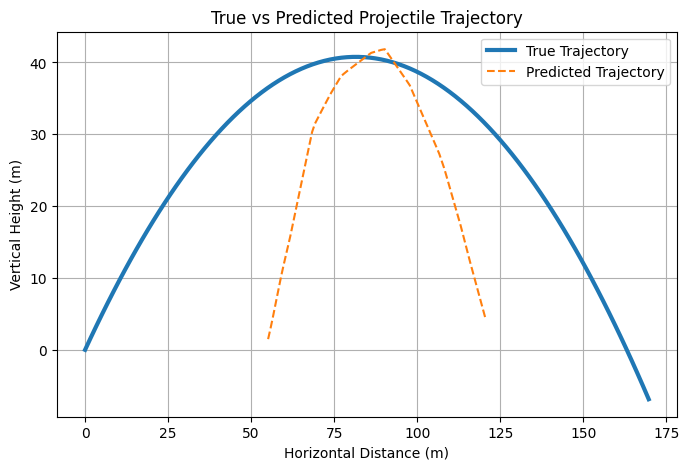

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(true_x_vals, true_y_vals, label="True Trajectory", linewidth=3)
plt.plot(pred_x_vals, pred_y_vals, '--', label="Predicted Trajectory")
plt.xlabel("Horizontal Distance (m)")
plt.ylabel("Vertical Height (m)")
plt.title("True vs Predicted Projectile Trajectory")
plt.legend()
plt.grid(True)
plt.show()